In [1]:
using Pkg
Pkg.activate("/home/chrisstrong/MRI_Driving/inverse-feedback-games/")
using iLQGames
import iLQGames: dx
using Plots
using ForwardDiff
using iLQGames:
    SystemTrajectory
using iLQGames:
    LinearSystem
using Infiltrator
using Optim
using LinearAlgebra
using Distributed
using Dates
using Statistics

include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

  Activating project at `~/MRI_Driving/inverse-feedback-games`


generate_expert_traj (generic function with 2 methods)

In [2]:
# added imports by Chris 
using BenchmarkTools
using LazySets
using LinearAlgebra
using Plots
using Random 

### Geometric utilities

In [3]:
# Abstract TrajectoryPlan type which 
# we want to be able to get distance from and distance along 
abstract type TrajectoryPlan end

"""
    Arc setup and Arc specific functions
"""
# These are directional with respect to calculating progress 
struct Arc <: TrajectoryPlan
    center
    radius
    start_angle
    end_angle
    clockwise::Bool

    function Arc(center, radius, start_angle, end_angle, clockwise::Bool=false)
        # Make sure the angles are between 0 and 2pi
        start_angle = mod(start_angle, 2*pi)
        end_angle = mod(end_angle, 2*pi)
    
        return new(center, radius, start_angle, end_angle, clockwise)
    end
end

function ordered_start_end_angle(start_angle, end_angle, clockwise)
# Makes the angles in the range [0, 4*pi) and orders them so that if you did a linspace 
# from start_angle to end_angle, you would get the arc.

# if you're going clockwise then start angle will be larger than end angle 
# if you're going counter clockwise then start angle will be smaller than end angle 
    if clockwise
        if start_angle < end_angle
            start_angle += 2 * pi
        end
    else
        if end_angle < start_angle
            end_angle += 2 * pi
        end
    end
    return start_angle, end_angle
end

function is_angle_between(angle, start_angle, end_angle, clockwise)
    # all angles must be between [0, 2pi)
    if clockwise
        if start_angle >= end_angle
            return start_angle >= angle >= end_angle
        else
            return angle <= start_angle || angle >= end_angle
        end
    else
        if start_angle <= end_angle
            return start_angle <= angle <= end_angle
        else
            return angle >= start_angle || angle <= end_angle
        end
    end
end


function sampled_projection(point, arc::Arc; num_samples::Int=1000)
    start_angle, end_angle = ordered_start_end_angle(arc.start_angle, arc.end_angle, arc.clockwise)
    angles = LinRange(arc.start_angle, arc.end_angle, num_samples)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    # project the point onto the arc
    distances = [norm(point - p) for p in points]
    min_distance, min_index = findmin(distances)

    return points[min_index]
end

function length(arc::Arc)
    start_angle, end_angle = ordered_start_end_angle(arc.start_angle, arc.end_angle, arc.clockwise)
    return arc.radius * abs(end_angle - start_angle)
end

function contains(arc::Arc, point)
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    return is_angle_between(angle, arc.start_angle, arc.end_angle, arc.clockwise)
end

function project(point, arc::Arc)
    # find the angle of the point with respect to the center of the arc
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    start_angle, end_angle = arc.start_angle, arc.end_angle

    # now, check if the angle is within the arc. if it is, then the projected point 
    # is in the interior of the arc. otherwise, it's one of the edge points. 
    if is_angle_between(angle, start_angle, end_angle, arc.clockwise)
        projected_point = arc.center .+ arc.radius * [cos(angle), sin(angle)]
    else
        start_vertex = arc.center .+ arc.radius * [cos(start_angle), sin(start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(end_angle), sin(end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        if distance_start_vertex < distance_end_vertex
            projected_point = start_vertex
        else
            projected_point = end_vertex
        end
    end 

    return projected_point
end 

function progress(point, arc::Arc)
    # Point should be on the arc TODO: assert that  
    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    if arc.clockwise 
        if angle > arc.start_angle 
            # then it will go all the way down to 0, then jump to 2pi and continue down until it hits it 
            angle_change = arc.start_angle + (2*pi - angle)
        else 
            angle_change = arc.start_angle - angle
        end
    else 
        if angle < arc.start_angle 
            # then it will go all the way up to 2pi, jump to 0, then continue until it hits it 
            angle_change = 2*pi - arc.start_angle + angle
        else
            angle_change = angle - arc.start_angle
        end
    end
    return angle_change * arc.radius

    # angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    # return mod(angle - arc.start_angle, 2*pi) * arc.radius
end

function point_from_progress(progress, arc::Arc)
    angle_change = progress / arc.radius
    angle = arc.start_angle + sign(arc.end_angle - arc.start_angle) * angle_change
    return arc.center + arc.radius .* [cos(angle), sin(angle)]
end

function visualize(arc::Arc)
    angles = LinRange(arc.start_angle, arc.end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    return plot!([p[1] for p in points], [p[2] for p in points], label="")
end

"""
    Line segment specific functions
"""

function length(line::LineSegment)
    return norm(line.q - line.p)
end

function contains(line::LineSegment, point)
    # Check if the point is on the line segment 
    return norm(point - line.p) + norm(point - line.q) ≈ length(line)
end

function project(point, line::LineSegment)
    # Project the point onto the line segment 
    v = line.q - line.p
    w = point - line.p
    c = dot(w, v) / dot(v, v)

    # if c is less than 0, then the closest point is the start point
    if c <= 0
        return line.p
    end

    # if c is greater than 1, then the closest point is the end point
    if c >= 1
        return line.q
    end

    return line.p + c * v
end

function progress(point, line::LineSegment)
    # Point should be on the line segment TODO: assert that 
    return norm(point - line.p) # distance from the start point 
end

function visualize(l::LineSegment)
    return plot!(l, label="")
end

"""
    Trajectory plan that contains several subtrajectories 
"""
struct ListTrajectoryPlan <: TrajectoryPlan
    subtrajectories
end

function length(trajectory::ListTrajectoryPlan)
    return sum([length(subtrajectory) for subtrajectory in trajectory.subtrajectories])
end

function contains(trajectory::ListTrajectoryPlan, point)
    for subtrajectory in trajectory.subtrajectories
        if contains(subtrajectory, point)
            return true
        end
    end
    return false
end

function project(point, trajectory::ListTrajectoryPlan)
    # Project the point onto each subtrajectory and return the closest one 
    projected_points = [project(point, subtrajectory) for subtrajectory in trajectory.subtrajectories]
    distances = [norm(point - projected_point) for projected_point in projected_points]
    min_distance, min_index = findmin(distances)

    return projected_points[min_index]
end

function progress(point, trajectory::ListTrajectoryPlan)
    accumulated_progress = 0
    for subtrajectory in trajectory.subtrajectories
        if contains(subtrajectory, point)
            return accumulated_progress + progress(point, subtrajectory)
        else
            accumulated_progress += length(subtrajectory)
        end 
    end
end

function visualize(trajectory::ListTrajectoryPlan)
    for subtrajectory in trajectory.subtrajectories
        visualize(subtrajectory)
    end
    return plot!()
end

"""
    Generic functions for any of our types of sets
"""
# For this to work for a set, need project(point, set) and progress(point, set) to be defined.
function project_frenet_coordinates(point, set)
    projected_point = project(point, set)

    # Distance along curve is the first new coordinate (the progress)
    distance_along_curve = progress(projected_point, set)

    # Distance from the curve is the second new coordinate 
    distance_from_curve = norm(point - projected_point)

    return distance_along_curve, distance_from_curve, projected_point 
end

function distance_and_projection(point, set)
    projected_point = project(point, set)
    distance = norm(point - projected_point)
    return distance, projected_point
end 


distance_and_projection (generic function with 1 method)

#### Testing the geometric utilities

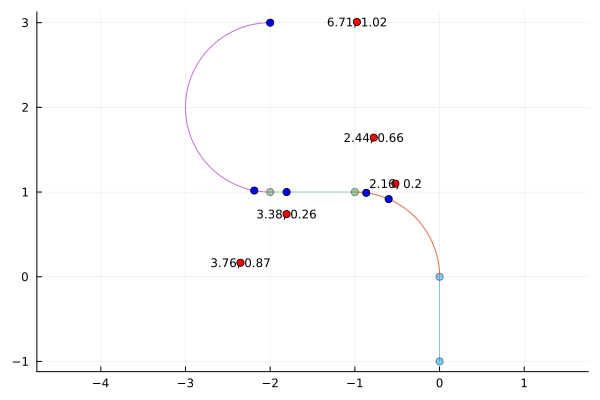

In [4]:
plot()
line_segment_1 = LineSegment([0., -1], [0., 0])
curve_1 = Arc([-1., 0], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 1], [-2., 1])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
visualize(trajectory)

# equal axis scale
plot!(aspect_ratio=:equal)


# benchmark time to project 1000 points onto the trajectory
points = [5 * rand(2) .- 1 for _ in 1:1000]
#@btime project(point, trajectory) setup=(point=3*rand(2) .- 1)

# generate random points, project onto trajectory 
num_points = 5
points = [[3 * rand(), 5 * rand()] - [3, 1] for _ in 1:num_points]

# for each point get its frenet coordinates and the point 
frenet_results = [project_frenet_coordinates(point, trajectory) for point in points]
distances_along_curve, distances_from_curve, projected_points = zip(frenet_results...)

for (point, distance_along_curve, distance_from_curve) in zip(points, distances_along_curve, distances_from_curve)
    scatter!([point[1]], [point[2]], color="red")
    # label each with distance along curve and distance from curve after rounding to 2 digits
    label = "$(round(distance_along_curve, digits=2)), $(round(distance_from_curve, digits=2))"
    annotate!([point[1]], [point[2]], text(label, 8, :black))
end

for point in projected_points
    scatter!([point[1]], [point[2]], color="blue")
end
# remove legend
plot!(legend=false)


### Testing the Solver

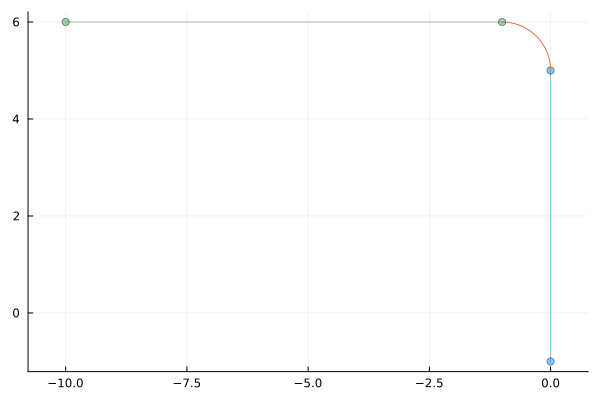

In [5]:
# trajectory to try to get it to track 
plot()
line_segment_1 = LineSegment([0., -1], [0., 5])
curve_1 = Arc([-1., 5], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 6], [-10., 6])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
# trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
trajectory_plan = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2])

visualize(trajectory_plan)
plot!(aspect_ratio=:equal)

#### Two Players

In [6]:
function relu(x)
    return max.(0, x)
end

relu (generic function with 1 method)

In [7]:
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end

# setup the dynamics
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()

# some parameters for the cost function 
ego_v_desired = 1.5
other_v_desired = 1.0
ego_comfortable_distance = 0.5

ego_weight_distance_along_curve = 1.0
ego_weight_distance_from_curve = 60.0
ego_weight_velocity = 5.0
ego_weight_control = 1.0
ego_weight_distance = 100.0

other_weight_distance_along_curve = 1.0
other_weight_distance_from_curve = 30.0
other_weight_velocity = 10.0
other_weight_control = 1.0



function distance_within_arc(point, arc)
    #arc = Arc([-9., 0.], 10., 0., pi/2, false)
    # assume we're inside the arc 

    angle = mod(atan(point[2] - arc.center[2], point[1] - arc.center[1]), 2*pi)
    if arc.start_angle <= angle <= arc.end_angle
        return arc.radius - norm(point - arc.center)
    else 
        # find the two endpoints of the arc, return the minimum distance to them 
        start_vertex = arc.center .+ arc.radius * [cos(arc.start_angle), sin(arc.start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(arc.end_angle), sin(arc.end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        return min(distance_start_vertex, distance_end_vertex)
    end
end

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

# Define the cost functions for each player 
function ego_vehicle_cost(g, x, u, t)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
    distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
end
    
function other_vehicle_cost(g, x, u, t)
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

    #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
    return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
end

function parameterized_cost(theta)
end


costs = (FunctionPlayerCost(ego_vehicle_cost), FunctionPlayerCost(other_vehicle_cost))

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)

# get a solver, choose initial conditions and solve (in about 9 ms with AD)
ego_x_0 = 0.5

x0 = SVector(0.0, 2.5, pi/2, 1,       0.0, 4, pi/2, 1,         0.2)

# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)

┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: You are using the fallback linearization using ForwardDiff. Consider
│     implementing a custom `linearize` or `linearize_discrete` for your
│     `ControlSystem` type.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/control_system.jl:122
┌ Warning: You are using the fallback quadraticization using ForwardDiff.
│     Consider implementing a custom `quadraticize` for your `ControlSystem`
│     type.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/quadraticize.jl:8


(true, SystemTrajectory{80, 0.1, 9, 4, SizedVector{80, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{80, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.0, 2.5, 1.5707963267948966, 1.0, 0.0, 4.0, 1.5707963267948966, 1.0, 0.2], [4.8323027048441835e-6, 2.607381901619082, 1.5707083407942464, 1.147638035247887, -0.0005046009568260711, 4.105605032484491, 1.5801864615314551, 1.1121325129018853, 0.2], [7.141687324322068e-5, 2.7279443518772464, 1.5697943998054322, 1.2636114215061536, -0.0024695211768324963, 4.220807745113592, 1.5953396059394453, 1.192278894271034, 0.2], [0.00032350757056535495, 2.858836083908161, 1.5679674422821037, 1.3542284381717051, -0.006817170071349734, 4.34279327892528, 1.6173338449100854, 1.2490300204778682, 0.2], [0.0009130449291876773, 2.9977726384777954, 1.5651624910365691, 1.4245285791786575, -0.014632490831598264, 4.469433285639239, 1.6473717983291056, 1.2886839869981546, 0.2], [0.0020083056029792413, 3.142921583363743, 1.

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_turning_vs=[1.5, 1.0]_comfortabledist=0.5.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/example_turning_vs=[1.5, 1.0]_comfortabledist=0.5.gif")
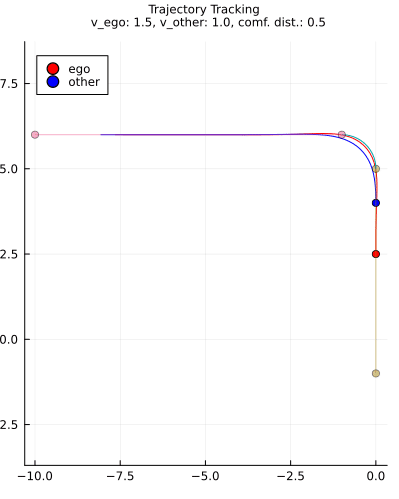

In [8]:
# Visualize the results 
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]

anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, color="red", label="")
    plot!(agent2_x, agent2_y, color="blue", label="")
    scatter!([agent1_x[t]], [agent1_y[t]], label="ego", legend=:topleft, color="red")
    scatter!([agent2_x[t]], [agent2_y[t]], label="other", legend=:topleft, color="blue")
    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft)
    visualize(trajectory_plan)
    plot!(title="Trajectory Tracking \n v_ego: $ego_v_desired, v_other: $other_v_desired, comf. dist.: $ego_comfortable_distance", titlefontsize=8)
end
save_file = string("visualizations/example_turning_vs=[",  ego_v_desired, ", ", other_v_desired, "]_comfortabledist=", ego_comfortable_distance, ".gif")
gif(anim, save_file, fps = 5)


In [ ]:
# Define the cost functions for each player 
function ego_vehicle_cost(g, x, u, t, theta)
    # cost for ego vehicle
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])

    distance_between_vehicles = norm([ego_x, ego_y] - [other_x, other_y])
    distance_penalty = relu(ego_comfortable_distance - distance_between_vehicles)^2

    ego_weight_distance_along_curve = theta[1]
    return -ego_weight_distance_along_curve * ego_distance_along_curve + ego_weight_distance_from_curve * ego_distance_from_curve^2 + ego_weight_velocity * (ego_v - ego_v_desired)^2 + ego_weight_control * (u[1]^2 + u[2]^2) + ego_weight_distance*distance_penalty
end
    
function other_vehicle_cost(g, x, u, t, theta)
    ego_x, ego_y, ego_phi, ego_v = x[1:4]
    other_x, other_y, other_phi, other_v = x[5:8]
    desired_x = x[9]
    other_distance_along_curve, other_distance_from_curve = wrapper_fcn([other_x, other_y])

    #return 10 * (other_v - 1)^2 + 100 * (u[3]^2 + u[4]^2)
    return -other_weight_distance_along_curve * other_distance_along_curve + other_weight_distance_from_curve * other_distance_from_curve^2 + other_weight_velocity * (other_v - other_v_desired)^2 + other_weight_control * (u[3]^2 + u[4]^2)
end

function parameterized_cost(theta)
    return (FunctionPlayerCost(g, x, u, t -> ego_vehicle_cost(g, x, u, t, theta)), FunctionPlayerCost(g, x, u, t -> other_vehicle_cost(g, x, u, t, theta)))
end

### Loading actual data

In [107]:
using NPZ


train_deonstrations_filename = "/home/shared/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.npz"
train_demonstrations = npzread(train_deonstrations_filename)

MethodError: MethodError: no method matching npzread(::String; vars::Vector{String})

Closest candidates are:
  npzread(::AbstractString, !Matched::Any...) got unsupported keyword argument "vars"
   @ NPZ ~/.julia/packages/NPZ/UCofn/src/NPZ.jl:269
  npzread(!Matched::ZipFile.Reader) got unsupported keyword argument "vars"
   @ NPZ ~/.julia/packages/NPZ/UCofn/src/NPZ.jl:289
  npzread(!Matched::ZipFile.Reader, !Matched::Any) got unsupported keyword argument "vars"
   @ NPZ ~/.julia/packages/NPZ/UCofn/src/NPZ.jl:289


### Old little examples

In [54]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

"Forward Game Problem: generate expert demo"
# parametes: number of states, number of inputs, sampling time, horizon
nx, nu, ΔT, game_horizon = 9, 4, 0.1, 40

# setup the dynamics
struct DoubleUnicycle <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::DoubleUnicycle, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1], u[2], 
                                    x[8]cos(x[7]), x[8]sin(x[7]), u[3], u[4],0)
dynamics = DoubleUnicycle()
costs = (FunctionPlayerCost((g, x, u, t) -> (  8*(x[1]-x[9])^2  +  2*(u[1]^2 + u[2]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) )),
        FunctionPlayerCost((g, x, u, t) -> (  8*(x[5] - x[9])^2 + 2*(u[3]^2 + u[4]^2) + 20*relu( 1- (x[5]-x[1])^2 - (x[6]-x[2])^2 ) ))   )

# indices of inputs that each player controls
player_inputs = (SVector(1,2), SVector(3,4))
# the horizon of the game
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)



# get a solver, choose initial conditions and solve (in about 9 ms with AD)
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    0.2)
# if we want to solve an LQ game, then consider running the following 2 lines of codes:
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, x0)


┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5
┌ Warning: The uids are not checked for duplicates.
└ @ iLQGames /home/chrisstrong/MRI_Driving/inverse-feedback-games/src/game_impl.jl:5


(true, SystemTrajectory{40, 0.1, 9, 4, SizedVector{40, SVector{9, Float64}, Vector{SVector{9, Float64}}}, SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}}}(SVector{9, Float64}[[0.5, 0.0, 1.5707963267948966, 1.0, 1.0, 1.0, 1.5707963267948966, 1.0, 0.2], [0.4973611620980389, 0.10034553422755002, 1.6233109193027642, 1.0078352194056186, 0.9930999485023164, 1.1020806916886978, 1.7047366810183568, 1.047802644056175, 0.2], [0.4899325760810583, 0.2012118042885135, 1.6652617938869723, 1.0151021128474578, 0.9731602135450084, 1.207148607796182, 1.811219734057159, 1.0920731545938351, 0.2], [0.47867765897504827, 0.3024114897026968, 1.6978165493632393, 1.0214602077374169, 0.9422919252764401, 1.3138864302456423, 1.8929322212715154, 1.130779506497138, 0.2], [0.4644720177330545, 0.40382894842563893, 1.7220863297626186, 1.0267405599525907, 0.9027333146309233, 1.4215206366339999, 1.952787978829254, 1.1630323911971088, 0.2], [0.4480987630903331, 0.5053987792200574, 1.739148788293023, 1.03

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
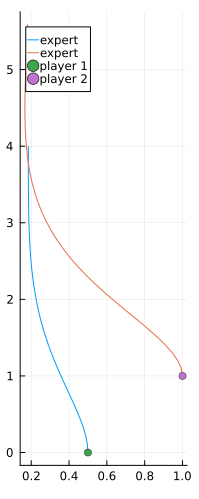

In [55]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
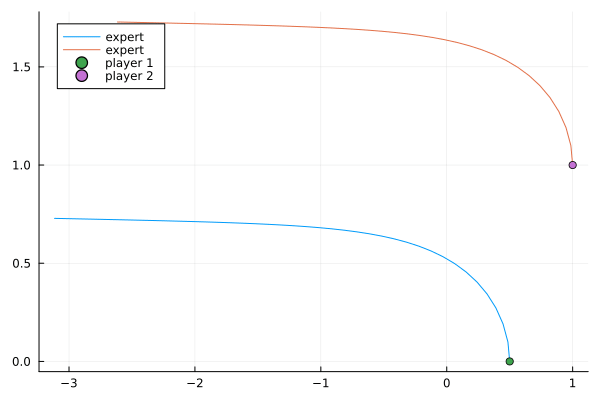

In [57]:
agent1_x = [expert_traj.x[t][1] for t in 1:game_horizon]
agent1_y = [expert_traj.x[t][2] for t in 1:game_horizon]
agent1_θ = [expert_traj.x[t][3] for t in 1:game_horizon]
agent1_v = [expert_traj.x[t][4] for t in 1:game_horizon]

agent2_x = [expert_traj.x[t][5] for t in 1:game_horizon]
agent2_y = [expert_traj.x[t][6] for t in 1:game_horizon]
agent2_v = [expert_traj.x[t][8] for t in 1:game_horizon]
agent2_θ = [expert_traj.x[t][7] for t in 1:game_horizon]
anim=@animate for t in 1:game_horizon
    plot(agent1_x, agent1_y, label="expert", legend=:topleft)
    plot!(agent2_x, agent2_y, label="expert", legend=:topleft)
    scatter!([agent1_x[t]], [agent1_y[t]], label="player 1", legend=:topleft)
    scatter!([agent2_x[t]], [agent2_y[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)
# scatter(agent1_x, agent1_y, label="player 1", legend=:topleft)
# scatter!(agent2_x, agent2_y, label="player 2", legend=:topleft)
# plot!(size=(200,500))



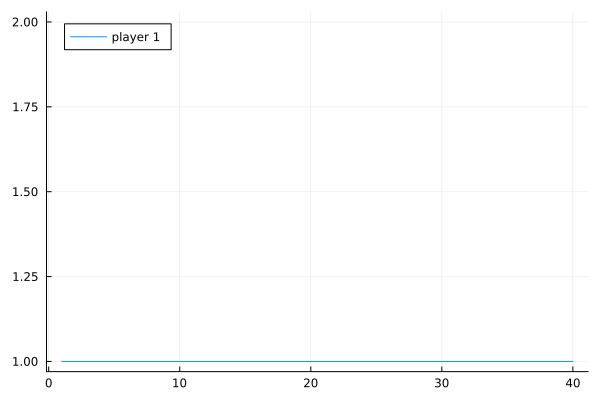

In [58]:
plot(agent1_v, label="player 1", legend=:topleft)

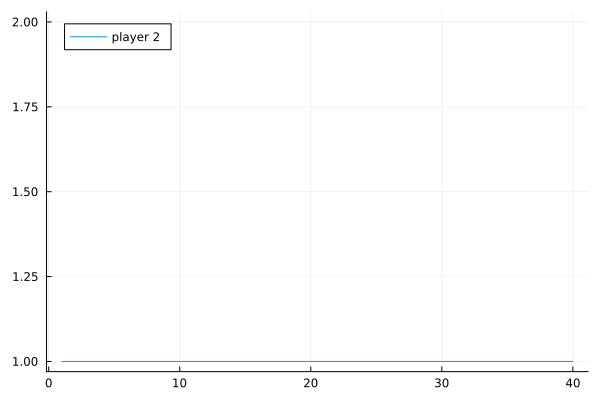

In [59]:
plot(agent2_v, label="player 2", legend=:topleft)

In [60]:
expert_traj.u

40-element SizedVector{40, SVector{4, Float64}, Vector{SVector{4, Float64}}} with indices SOneTo(40):
 [2.8208899564666567, 0.0, 2.8208899564666567, 0.0]
 [2.3103157625285986, 0.0, 2.3103157625285986, 0.0]
 [1.8921541990916841, 0.0, 1.8921541990916841, 0.0]
 [1.5496788036184368, 0.0, 1.5496788036184368, 0.0]
 [1.2691905602899265, 0.0, 1.2691905602899265, 0.0]
 [1.0394699393730127, 0.0, 1.0394699393730127, 0.0]
 [0.8513281160310212, 0.0, 0.8513281160310212, 0.0]
 [0.6972394173302706, 0.0, 0.6972394173302706, 0.0]
 [0.5710402953227296, 0.0, 0.5710402953227296, 0.0]
 [0.46768278512809824, 0.0, 0.46768278512809824, 0.0]
 ⋮
 [0.0056274918689571095, 0.0, 0.0056274918689571095, 0.0]
 [0.004546015654581799, 0.0, 0.004546015654581799, 0.0]
 [0.0036463800663897386, 0.0, 0.0036463800663897386, 0.0]
 [0.002892599680854445, 0.0, 0.002892599680854445, 0.0]
 [0.0022545232825521705, 0.0, 0.0022545232825521705, 0.0]
 [0.001706627815552515, 0.0, 0.001706627815552515, 0.0]
 [0.0012269974611747118, 0.0, 0

In [61]:
# implement the receding horizon planning:
x0 = SVector(
    0.5, 0., pi/2, 1,       
    1, 1, pi/2, 1,         
    pi)
trajectory = [x0]
T = 3
for t in 1:T
    # 1. get the current state
    x = trajectory[end]
    # 2. solve the game with the current state
    c, expert_traj, strategies = solve(g, solver, x)
    # 3. get the optimal control
    u1 = expert_traj.u[1][1:2]
    u2 = expert_traj.u[1][3:4]
    # 4. apply the control to the system
    x = dx(dynamics, x, [u1; u2], t)
    print(x)
    push!(trajectory, x)
end


[6.123233995736766e-17, 1.0, 2.8208899564666567, 0.0, 6.123233995736766e-17, 1.0, 2.8208899564666567, 0.0, 0.0][-0.0, 0.0, -5.025962410977983, 0.0, -0.0, 0.0, -5.025962410977983, 0.0, 0.0][0.0, 0.0, 9.025795798514084, 0.0, 0.0, 0.0, 9.025795798514084, 0.0, 0.0]

┌ Info: Saved animation to 
│   fn = /home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif
└ @ Plots /home/chrisstrong/.julia/packages/Plots/UeTBV/src/animation.jl:114


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/expert_demo.gif")
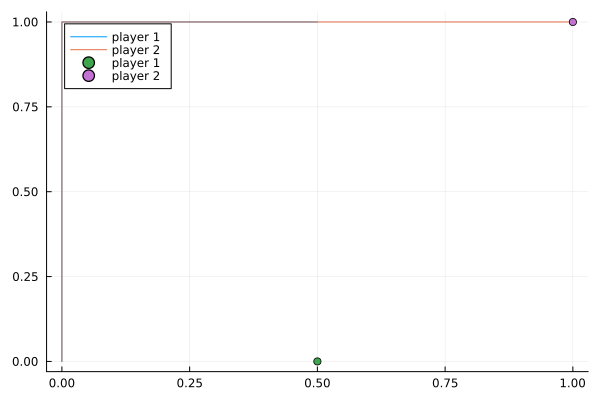

In [63]:

x1 = [trajectory[t][1] for t in 1:T]
y1 = [trajectory[t][2] for t in 1:T]
θ1 = [trajectory[t][3] for t in 1:T]
v1 = [trajectory[t][4] for t in 1:T]

x2 = [trajectory[t][5] for t in 1:T]
y2 = [trajectory[t][6] for t in 1:T]
v2 = [trajectory[t][8] for t in 1:T]
θ2 = [trajectory[t][7] for t in 1:T]

anim=@animate for t in 1:T
    plot(x1, y2, label="player 1", legend=:topleft)
    plot!(x2, y2, label="player 2", legend=:topleft)
    scatter!([x1[t]], [y1[t]], label="player 1", legend=:topleft)
    scatter!([x2[t]], [y2[t]], label="player 2", legend=:topleft)
    plot!(equal_aspect_ratio=true)
    # plot!(size=(200,500))
end
gif(anim, "expert_demo.gif", fps = 5)

In [65]:
# new cost function for arc projection:
struct Arc
    center::Vector{Float64}
    radius::Float64
    start_angle::Float64
    end_angle::Float64
end

function sampled_projection(point::Vector{Float64}, arc::Arc, num_samples::Int)
    angles = LinRange(arc.start_angle, arc.end_angle, num_samples)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    # project the point onto the arc
    distances = [norm(point - p) for p in points]
    min_distance, min_index = findmin(distances)

    return points[min_index]
end

function project(point::Vector{Float64}, arc::Arc)
    # find the angle of the point with respect to the center of the arc
    angle = atan(point[2] - arc.center[2], point[1] - arc.center[1])

    # check if the angle is within the arc accounting for the 2pi rollover
    # first make sure start_angle < end_angle and angle > start_angle 
    start_angle = arc.start_angle % (2 * pi)
    end_angle = arc.end_angle % (2 * pi)
    if end_angle < start_angle
        end_angle += 2 * pi
    end

    if angle < start_angle
        angle += 2 * pi
    end

    # now, check if the angle is within the arc. if it is, then the projected point 
    # is in the interior of the arc. otherwise, it's one of the edge points. 
    if start_angle <= angle <= end_angle
        projected_point = arc.center .+ arc.radius * [cos(angle), sin(angle)]
    else
        start_vertex = arc.center .+ arc.radius * [cos(start_angle), sin(start_angle)]
        end_vertex = arc.center .+ arc.radius * [cos(end_angle), sin(end_angle)]
        distance_start_vertex = norm(point - start_vertex)
        distance_end_vertex = norm(point - end_vertex)
        if distance_start_vertex < distance_end_vertex
            projected_point = start_vertex
        else
            projected_point = end_vertex
        end
    end 

    return projected_point
end 

function project_and_distance(point, set)
    projected_point = project(point, set)
    distance = norm(point - projected_point)
    return projected_point, distance
end 

function plot_arc(arc::Arc)
    angles = LinRange(arc.start_angle, arc.end_angle, 100)
    points = [arc.center .+ arc.radius * [cos(angle), sin(angle)] for angle in angles]

    plot!([p[1] for p in points], [p[2] for p in points])
end


ErrorException: invalid redefinition of constant Arc

In [66]:
arc = Arc([0.0, 0.0], 1.0, 0, pi/2)
point = [2 * rand() - 1, 2 * rand() - 1]
projected_point = project(point, arc)
plot(equal_aspect_ratio=true)
plot_arc(arc)
scatter!([point[1]], [point[2]], label="point")
scatter!([projected_point[1]], [projected_point[2]], label="projected point")



UndefVarError: UndefVarError: `plot_arc` not defined